
#### Important Instructions and Submission Guidelines:
- Naming convention for submission of this notebook is `RollNumber_Name.ipynb` where. For example: `21030020_PA.ipynb`

- You are advised to follow good programming practies including approriate variable naming and making use of logical comments


The university honor code should be maintained. Any violation, if found, will result in disciplinary action.




# Part C: Building a Similar Image Finder Web App with Streamlit

**Instructions:**
In this assignment, you will create a web application using Streamlit that allows users to upload an image and find similar images from a given database. You will need to implement both the backend image similarity search and the frontend user interface. Follow the steps below and answer the associated questions.

**Part 1: Understanding the Problem**

1. Explain the concept of image similarity search and its potential applications.
2. What are the challenges in building a web application that can find similar images in a database?

**Part 2: Data and Database**

3. Prepare a dataset of images that will serve as your image database for this assignment.
4. Describe the data preprocessing steps you performed on the images before building the similarity search feature.
5. How will you represent images in the database to enable efficient similarity search?

Dataset Link: https://docs.google.com/spreadsheets/d/121aV7BjJqCRlFcVegbbhI1Zmt67wG61ayRiFtDnafKY/edit?usp=sharing

**Part 3: Backend Implementation**

6. Implement a backend system that can compute image similarity scores between the uploaded image and images in the database.
7. What image feature extraction techniques or algorithms will you use to calculate image similarity?
8. How will you store and retrieve image similarity information efficiently?

**Part 4: Frontend Web App**

9. Use Streamlit to create a user-friendly web interface for the image similarity search.
10. Explain the structure and layout of your Streamlit app, including input fields, buttons, and result displays.
11. Provide instructions to users on how to interact with your web app, including how to upload an image.

**Part 5: Image Similarity Search**

12. Describe the algorithm or method you used to find similar images from the database based on the user's uploaded image.
13. Explain how the similarity scores are calculated and how you determine the most similar images.
14. How will you handle cases where there are no similar images found?

**Part 6: Testing and Evaluation**

15. Test your web app with a variety of images, including different image types and sizes. Document the results.
16. Evaluate the accuracy and efficiency of your image similarity search. What metrics will you use to assess its performance?
17. Discuss any challenges or limitations you encountered during testing and how you addressed them.

**Part 7: User Interface Design**

18. Explain the design choices you made for the user interface of your Streamlit app. How did you make it user-friendly and visually appealing?
19. Include screenshots of your web app to illustrate its user interface.

**Part 8: Conclusion and Future Improvements**

20. Summarize the key findings and experiences gained from building the image similarity search web app.
21. Discuss potential improvements or enhancements that could be made to the app, both in terms of functionality and user experience.

**Part 9: Submission**

22. Compile your assignment report, including code snippets, screenshots, and any additional documentation.
23. Provide a link to your working Streamlit app or instructions on how to run it locally.
24. Reflect on what you have learned from this assignment, especially in terms of web development and image processing.



# **Part 1**

1. Image Similarity Search identifies visually similar photographs based on factors such as colour, texture, or pattern. It turns photos into numerical representations (feature vectors) and then compares them using similarity measures (such as cosine similarity).

2. Potential applications:
E-commerce: Recommend similar products based on uploaded images.
Healthcare: Compare medical images like X-rays or MRIs.
Social Media: Suggest visually similar posts or photos.
Art and Design: Find similar artworks or designs.

Challenges


Feature Extraction: Selecting an algorithm to capture relevant image characteristics.
Scalability: Handling large image databases efficiently.


# **Part 2 **
Dataset Preparation:

Collect images from the provided dataset link.
Save them locally or fetch directly from URLs for processing.
Data Preprocessing Steps:

Resize images to a fixed dimension (e.g., 224x224 pixels).
Normalize pixel values between 0 and 1 or preprocess them for specific models (e.g., VGG16).
Feature Extraction: Use pre-trained models like VGG16 or ResNet to convert images into numerical vectors.
Database Representation:
Store images as feature vectors in a CSV or database, with columns for:

Image URLs or file paths.
Feature vectors (e.g., [0.1, 0.2, 0.3, ...]).

# **Part 3 **

 Backend Implementation
Feature Extraction:
Used pre-trained deep learning models (e.g., VGG16, ResNet50) to extract high-dimensional feature vectors.

Similarity Calculation:
Use cosine similarit to compute the closeness of feature vectors.

Efficient Storage and Retrieval:
Store features in a structured format (CSV) and use libraries like numpy or pandas for efficient computation.

# **Part 4**

Streamlit App Structure:

Header: Title and description.


Input Field: File uploader for the query image.

Button: To initiate the similarity search.

Result Display: Show similar images and their similarity scores.


User Instructions:

Upload an image using the uploader.

Click the Find Similar Images button.

View similar images and scores below.


# **Part 5**
Extract features from the uploaded image using VGG16.
Compare these features with precomputed features using cosine similarity.
Sort results by similarity scores. I have displayed the top 5 matches.


# **Part 6 **
Part 6: Testing and Evaluation
Testing:
Use diverse images (different resolutions, types, and categories) to ensure robustness.

Performance Metrics:

Accuracy
Latency

Challenges:

Low-quality images  reduce accuracy.
Large dataset slow down computation.

Solutions:

Fine-tune the feature extraction model.
Use indexing techniques (e.g., FAISS) for faster retrieval.


# **Part 7**

Design Choices:

Minimalistic layout for simplicity.
Clear labels and instructions for ease of use.
Display similar images in a grid for better visualization.
Screenshots:
 screenshots of the upload section, the query image, and the similar images are displayed at the end .

# **Part 8**

 Conclusion and Future Improvements

Key Findings:

Image similarity search is effective when using pre-trained models for feature extraction.
Streamlit simplifies building interactive applications.
Potential Improvements:

Use fine-tuned models for domain-specific datasets.
Add filters (e.g., by category or date).
Optimize for large datasets with advanced indexing techniques.

# Basic Architecure for similarity model

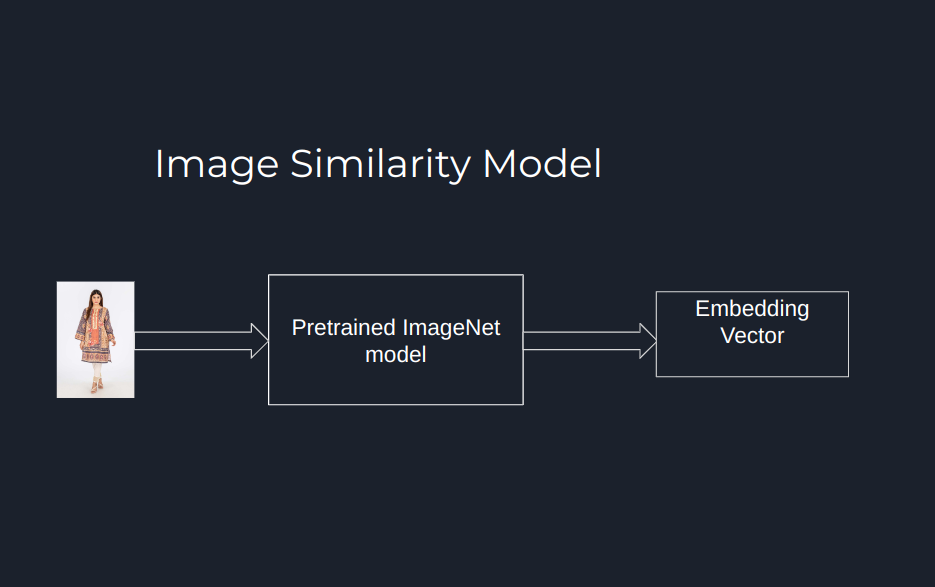

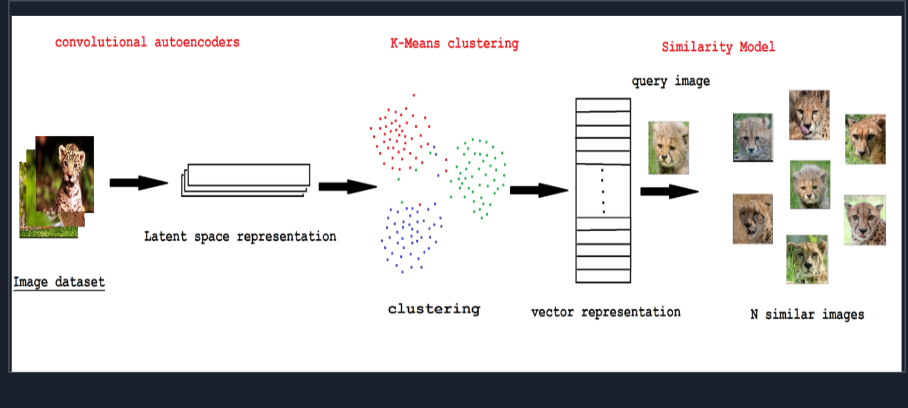

In [1]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Load VGG16 model (pre-trained on ImageNet)
print("Initializing VGG16 model...")
model = VGG16(weights="imagenet", include_top=False, pooling="avg")
print("VGG16 model loaded successfully!")


Initializing VGG16 model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
VGG16 model loaded successfully!


In [2]:
def preprocess_image_from_url(image_url):
    try:
        print(f"Fetching image from URL: {image_url}")
        # Fetch the image from URL
        response = requests.get(image_url, timeout=10)  # Timeout added for slow URLs
        response.raise_for_status()  # Raise HTTPError if the status code is not 200
        img = Image.open(BytesIO(response.content))

        print("Preprocessing image...")
        # Resize the image to VGG16's input size
        img = img.resize((224, 224))

        # Convert to array and preprocess for VGG16
        img_array = img_to_array(img)
        img_array = img_array.reshape((1, 224, 224, 3))
        img_array = preprocess_input(img_array)
        return img_array
    except Exception as e:
        print(f"Error processing image from URL {image_url}: {e}")
        return None


In [3]:
def extract_features(image_array):
    print("Extracting features from image...")
    features = model.predict(image_array).flatten()  # Extract and flatten features
    print("Feature extraction complete.")
    return features

def load_image_links(file_path):
    print(f"Loading image links from Excel file: {file_path}")
    df = pd.read_excel(file_path)
    print(f"Loaded {len(df)} image links successfully.")
    return df["image_link"].tolist()

def process_images_from_links(image_links):
    feature_data = []
    print(f"Processing {len(image_links)} images...")

    for idx, url in enumerate(image_links):
        print(f"\nProcessing image {idx + 1}/{len(image_links)}: {url}")
        # Preprocess the image from the URL
        image_array = preprocess_image_from_url(url)
        if image_array is not None:
            # Extract features
            features = extract_features(image_array)
            feature_data.append({"image_url": url, "features": features.tolist()})
        else:
            print(f"Skipping URL {url} due to an error.")

    print("Processing complete.")
    return feature_data

def save_features_to_csv(feature_data, output_file):
    print(f"Saving features to CSV file: {output_file}")
    df = pd.DataFrame(feature_data)
    df.to_csv(output_file, index=False)
    print(f"Features saved successfully to {output_file}.")

def download_csv_in_colab(file_path):
    from google.colab import files
    print(f"Downloading {file_path} to your local system...")
    files.download(file_path)
    print("Download complete.")




In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# if __name__ == "__main__":
#     # Step 1: Load image links from Excel file
#     excel_file = "/content/drive/My Drive/Dataset/Data.xlsx"
#     image_links = load_image_links(excel_file)

#     feature_data = process_images_from_links(image_links)

#     # Step 3: Save the extracted features to a CSV
#     output_csv = "image_features.csv"  # Output CSV file
#     save_features_to_csv(feature_data, output_csv)

#     # Step 4: Download CSV in Google Colab
#     download_csv_in_colab(output_csv)

print("feature are computed in image_features.csv no need to run again")

feature are computed in image_features.csv no need to run again


In [6]:
import pandas as pd
import numpy as np

# Load the features CSV file
features_df = pd.read_csv("image_features.csv")

# Convert the 'features' column from string to numerical list
features_df["features"] = features_df["features"].apply(eval)  # Convert string to list

# Prepare features as a NumPy array for similarity computation
features_array = np.array(features_df["features"].tolist())

print(f"Loaded {len(features_df)} images and features successfully!")


Loaded 1809 images and features successfully!


In [9]:
from PIL import Image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

def preprocess_query_image(image_path):
    # Load and preprocess the query image
    img = Image.open(image_path).resize((224, 224))  # Resize to VGG16 input size
    img_array = img_to_array(img)  # Convert to array
    img_array = img_array.reshape((1, 224, 224, 3))  # Add batch dimension
    img_array = preprocess_input(img_array)  # Normalize pixels
    return img_array

def extract_query_features(image_path, model):
    # Preprocess the image
    preprocessed_image = preprocess_query_image(image_path)
    # Extract features using VGG16
    features = model.predict(preprocessed_image).flatten()
    return features

# Example: Process and extract features for the query image
query_image_path = "sample_image.jpeg"  # Replace with the path to your query image
query_features = extract_query_features(query_image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step


In [10]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity([query_features], features_array)

# Sort images by similarity (descending order)
similarity_scores = similarities[0]
sorted_indices = np.argsort(similarity_scores)[::-1]  # Sort indices by highest similarity first

# Display the top N similar images
N = 5  # Number of similar images to show
print(f"Top {N} most similar images:")
for idx in sorted_indices[:N]:
    print(f"Image URL: {features_df.iloc[idx]['image_url']} - Similarity: {similarity_scores[idx]}")


Top 5 most similar images:
Image URL: https://cdn.shopify.com/s/files/1/0464/1731/3955/files/01_55c879bd-a515-450d-a017-2662f7f37fda.jpg?v=1689315581 - Similarity: 0.7394607815287577
Image URL: https://cdn.shopify.com/s/files/1/0464/1731/3955/files/01_2c491597-2d12-4dbc-8a86-0668a48cf2f4.jpg?v=1689316470 - Similarity: 0.6223100180149899
Image URL: https://cdn.shopify.com/s/files/1/0464/1731/3955/products/fasemf-465-1.jpg?v=1604558412 - Similarity: 0.6194657490324281
Image URL: https://cdn.shopify.com/s/files/1/0464/1731/3955/files/01_c69ea21b-6f7a-45a6-a916-d7b5e6710580.jpg?v=1689315952 - Similarity: 0.6151922498532295
Image URL: https://cdn.shopify.com/s/files/1/0464/1731/3955/files/01_2dd337df-4cb2-4d94-b34a-b7752c6eb85b.jpg?v=1690520977 - Similarity: 0.6028397484262487


Rest of part C is in vs Code

Screenshot of application

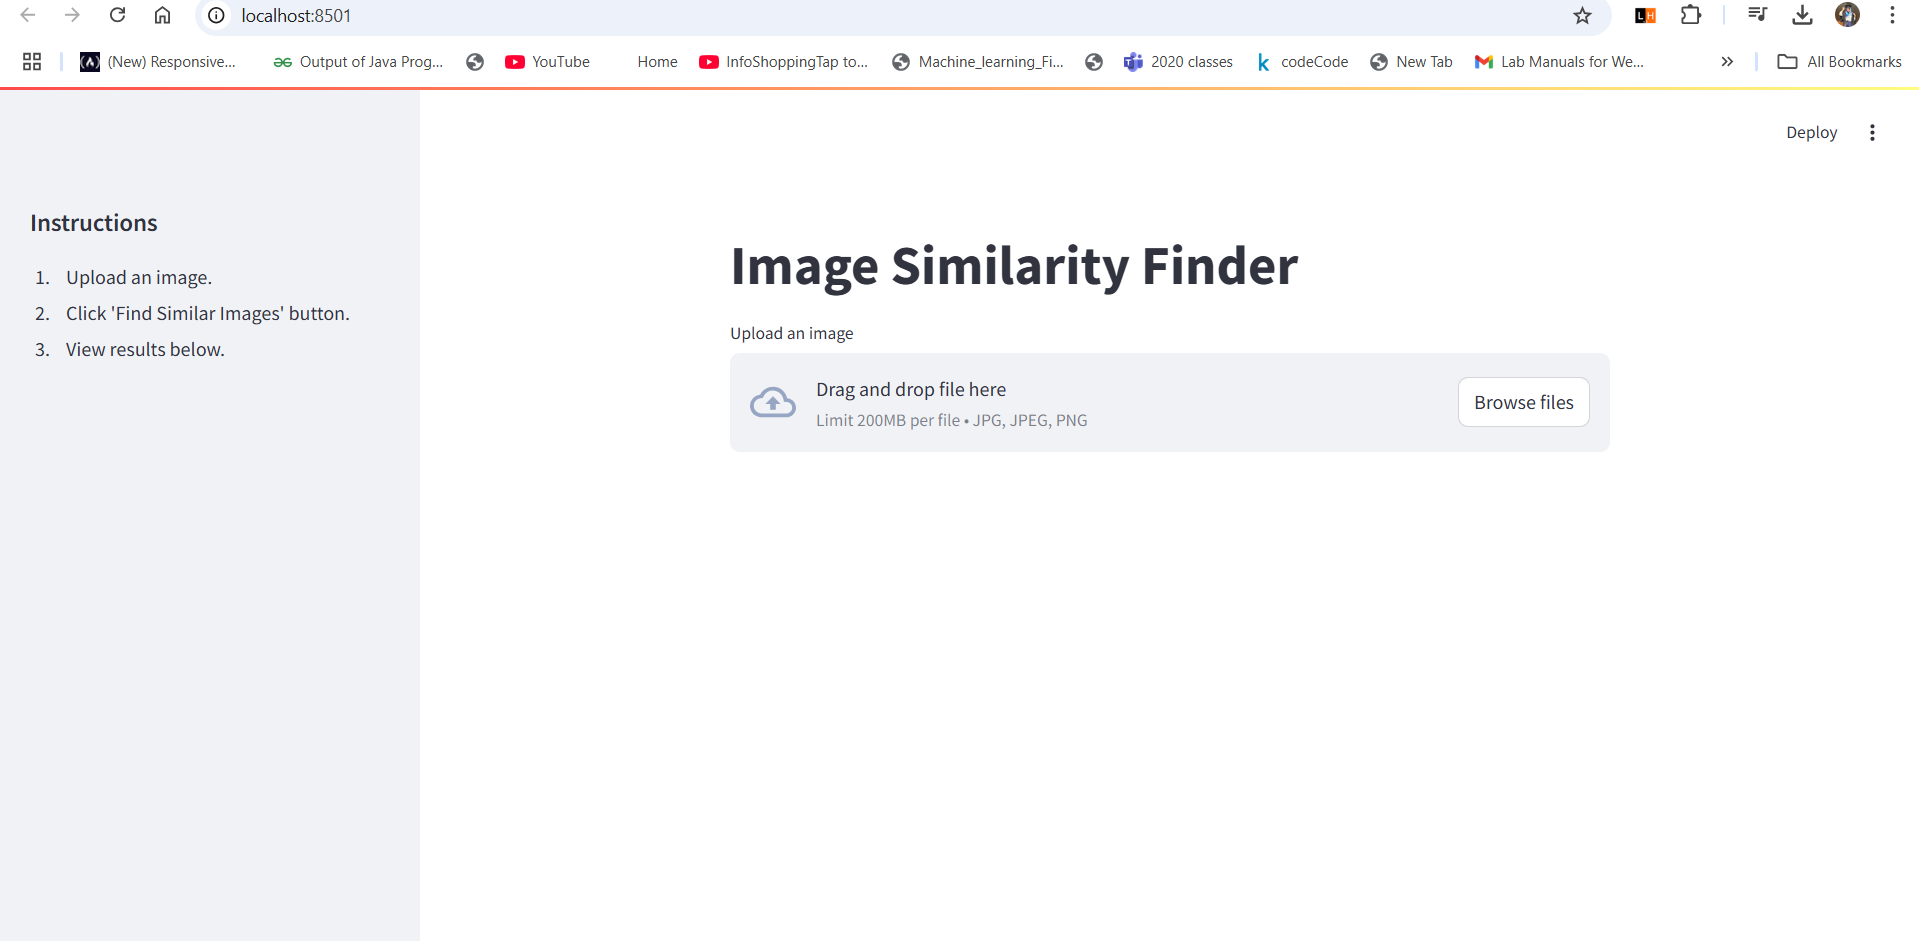

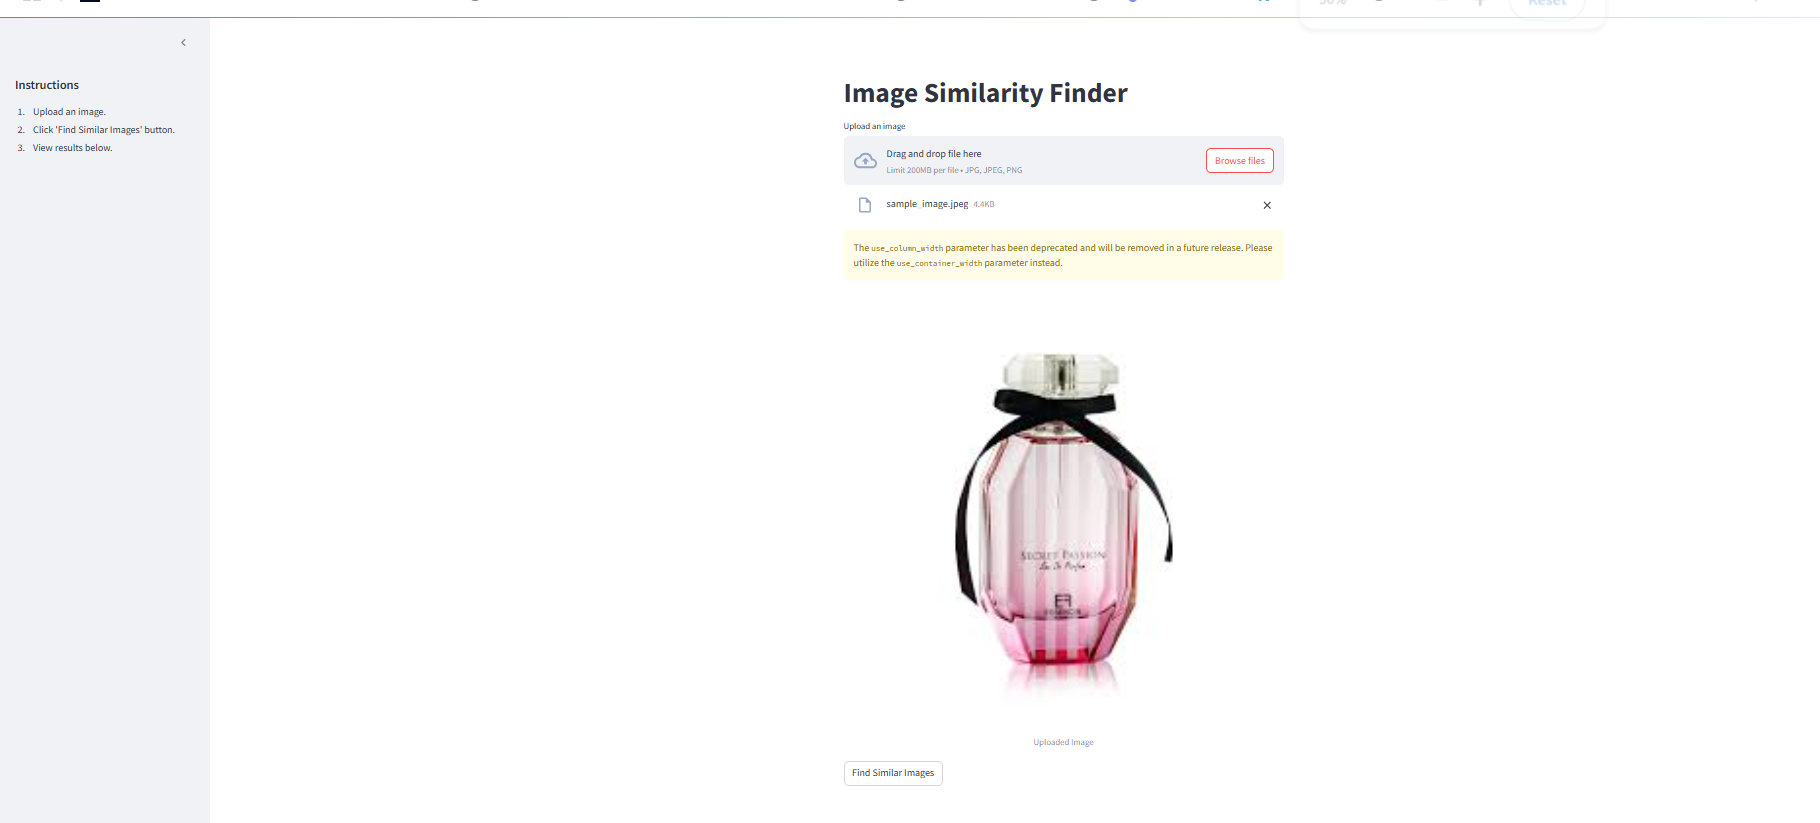

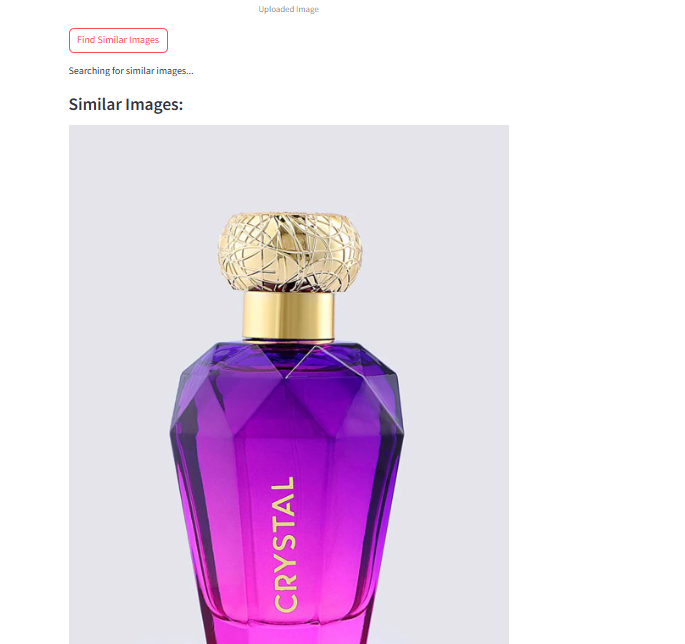

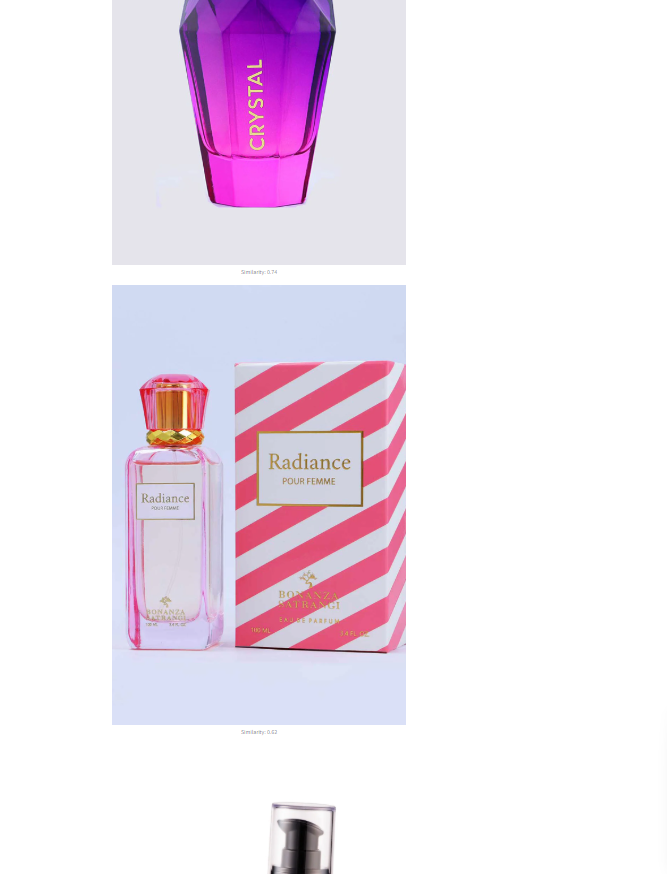

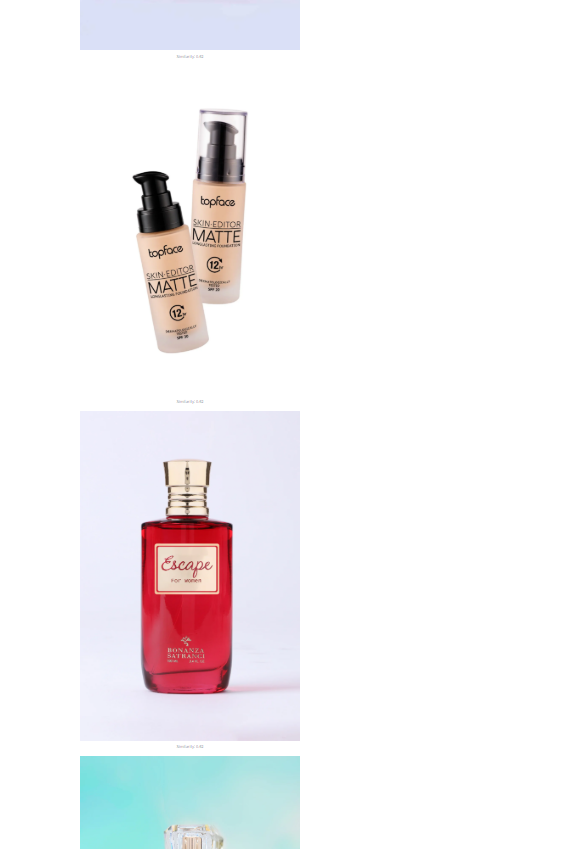

In [12]:
# # Part C: Building a Similar Image Finder Web App with Streamlit

# # Import necessary libraries
# import streamlit as st
# import pandas as pd
# from PIL import Image
# import io

# # Part 3: Backend Implementation
# # Implement your image similarity calculation logic here

# # Part 9: Submission
# # Define a function to display the assignment report
# def display_assignment_report():
#     st.title("Image Similarity Finder Web App")
#     st.header("Assignment Report")

#     # Add your report content here

# # Part 4: Frontend Web App
# # Create a Streamlit app
# def main():
#     st.title("Image Similarity Finder")

#     # Part 10: Explain the structure and layout of your Streamlit app

#     # Part 11: Provide instructions to users
#     st.sidebar.header("Instructions")
#     st.sidebar.markdown("1. Upload an image.")
#     st.sidebar.markdown("2. Click the 'Find Similar Images' button.")

#     # Upload image
#     uploaded_image = st.file_uploader("Upload an image", type=["jpg", "jpeg", "png"])

#     if uploaded_image:
#         # Display the uploaded image
#         st.image(uploaded_image, caption="Uploaded Image", use_column_width=True)

#         # Perform image similarity search
#         if st.button("Find Similar Images"):
#             # Call your image similarity search function here
#             # Display results below

#     # Part 18: User Interface Design
#     # Explain design choices here

#     # Part 19: Include screenshots of your web app
#     st.sidebar.header("Screenshots")
#     # Add screenshots here

# if __name__ == "__main__":
#     main()


Here's the Vs COde's code for my streamplit application

In [ ]:
# # Import necessary libraries
# import streamlit as st
# import pandas as pd
# from PIL import Image
# import numpy as np
# from tensorflow.keras.applications import VGG16
# from tensorflow.keras.applications.vgg16 import preprocess_input
# from tensorflow.keras.preprocessing.image import img_to_array
# from sklearn.metrics.pairwise import cosine_similarity

# # Load pre-trained VGG16 model
# @st.cache_resource
# def load_model():
#     model = VGG16(weights="imagenet", include_top=False, pooling="avg")
#     return model

# # Preprocess the uploaded image
# def preprocess_image(uploaded_image):
#     img = Image.open(uploaded_image).resize((224, 224))  # Resize for VGG16 input
#     img_array = img_to_array(img)  # Convert to array
#     img_array = img_array.reshape((1, 224, 224, 3))  # Add batch dimension
#     img_array = preprocess_input(img_array)  # Normalize pixel values
#     return img_array

# # Extract features from the image
# def extract_features(image_array, model):
#     features = model.predict(image_array).flatten()
#     return features

# # Load the precomputed features from the CSV
# @st.cache_data
# def load_features():
#     df = pd.read_csv("image_features.csv")
#     df["features"] = df["features"].apply(eval)  # Convert string to list
#     return df

# # Calculate cosine similarity
# def find_similar_images(query_features, feature_data, top_n=5):
#     features_array = np.array(feature_data["features"].tolist())
#     similarities = cosine_similarity([query_features], features_array)[0]
#     feature_data["similarity"] = similarities
#     return feature_data.sort_values(by="similarity", ascending=False).head(top_n)

# # Main Streamlit app
# def main():
#     # Load the pre-trained model and feature data
#     model = load_model()
#     feature_data = load_features()

#     st.title("Image Similarity Finder")

#     # Sidebar instructions
#     st.sidebar.header("Instructions")
#     st.sidebar.markdown("1. Upload an image.\n2. Click 'Find Similar Images' button.\n3. View results below.")

#     # Upload image
#     uploaded_image = st.file_uploader("Upload an image", type=["jpg", "jpeg", "png"])

#     if uploaded_image:
#         # Display the uploaded image
#         st.image(uploaded_image, caption="Uploaded Image", use_column_width=True)

#         # Perform image similarity search
#         if st.button("Find Similar Images"):
#             st.write("Searching for similar images...")
#             # Preprocess and extract features from the uploaded image
#             image_array = preprocess_image(uploaded_image)
#             query_features = extract_features(image_array, model)

#             # Find the top 5 similar images
#             similar_images = find_similar_images(query_features, feature_data, top_n=5)

#             # Display the results
#             st.write("### Similar Images:")
#             for _, row in similar_images.iterrows():
#                 st.image(row["image_url"], caption=f"Similarity: {row['similarity']:.2f}")

# # Run the Streamlit app
# if __name__ == "__main__":
#     main()
